In [1]:
import os
import argparse
import numpy as np
import pandas as pd
from decimal import *
import matplotlib.pyplot as plt
from tqdm import tqdm

In [57]:
def update_delta(gamma_j, beta):
    return 1/gamma_j * ((gamma_j*(beta - 1) + 1)**(1/(1 - beta)))

def update_eff(n_a, E_o, S_o, delta_e, k_C, n_d):
    # if E_o - n_a* S_o is positive, the exponential value of this expression will explode in calculation.
    # The original form of efficiency formula contains negative exponent and
    # the simplified form contains the positive exponent
    
    if (E_o - n_a*S_o) >= 0:
        return n_d * (n_a - \
                        ((E_o - n_a*S_o)*n_a*np.exp(-(E_o - n_a * S_o) * k_C * delta_e))/ \
                        (E_o - n_a*S_o*np.exp(-(E_o - n_a*S_o) * k_C * delta_e)))
    else:
        return n_d * (n_a - \
                    ((E_o - n_a*S_o) * n_a)/ \
                        (E_o * np.exp((E_o - n_a * S_o) * k_C * delta_e) - n_a * S_o))
    
def simulate_vals(D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=50):
    S_o, gamma, delta, n_a, eff = [], [], [], [], []
    P_o, E_o, D_e = [P_init], [E_init], [D_init]

    n_cycle = int(n_cycle)
    print(n_cycle)

    for i in range(n_cycle):
        S_o_j = n_d*D_e[i]
        S_o.append(S_o_j)

        gamma_j = S_o_j/(P_o[i] + Decimal(1e-200))
        gamma.append(gamma_j)
        
        print(gamma_j)

        delta_j = update_delta(gamma_j, beta=beta)
        delta.append(delta_j)

        n_a_j = 1/gamma_j - delta_j
        n_a.append(n_a_j)

        E_o_j = (n_dE**(i+1)) * E_o[0]
        E_o.append(E_o_j)

        eff_j = update_eff(n_a=n_a_j, E_o=E_o_j, S_o=S_o_j, delta_e=delta_e, k_C=k_C, n_d=n_d)
        eff.append(eff_j)
        # print('At cycle {}, PCR efficiency is {}'.format(i, eff_j))

        D_e_j = (eff_j + 1)*D_e[i]
        D_e.append(D_e_j)

        P_o_j = P_o[i] - eff_j * S_o_j
        P_o.append(P_o_j)
    
    return eff, n_a, D_e, S_o, E_o, P_o, gamma, delta

In [3]:
# define constants
k_C = Decimal(15)
n_d = Decimal(1)
n_dE = Decimal(0.99)

beta = Decimal(25)

delta_e = Decimal(100)

In [40]:
# Generating synthetic curve for comparison
D_init = Decimal(1000)
P_init = Decimal(9.e5)
E_init = Decimal(1e5)

D_e = simulate_vals(D_init=D_init,
                        E_init=E_init, 
                        P_init=P_init, 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=44)[2]

D_e = np.array([float(str(x)) for x in D_e])


# Reading in initial curve for comparison
known_df = pd.read_csv('./data/known_dilution_multicomponent.csv')
known_df.head(2)
curve = known_df.loc[(known_df.loc[:,'Well Position'] == 'A1'), 'FAM']
curve = np.array(curve)
# curve -= curve[0] #NOTE THAT WE ARE SHIFTING THE CURVE DOWN !!! NEED TO ADDRESS LATER

curve = D_e

def func_to_optimize(params):
    tried_params.append(params)
    
    D_e_cur = simulate_vals(D_init=Decimal(10**params[0]),
                        E_init=Decimal(10**params[1]), 
                        P_init=Decimal(10**params[2]), 
                        delta_e=Decimal(10**params[4]),
                        n_d=Decimal(10**0),
                        n_dE=Decimal(10**0),
                        k_C=Decimal(10**params[7]),
                        beta=Decimal(10**params[8]),
                        n_cycle=params[9])[2]
    D_e_cur = np.array([float(str(x)) + 10**params[3] for x in D_e_cur])[:len(curve)]
    return ((curve - D_e_cur)**2).mean()
        

<class 'int'>


In [5]:
from scipy.optimize import minimize

init_params = np.array([4, 6, 5, 5, 1, 0, 0, 1, 1, 44])
tried_params = []

res = minimize(func_to_optimize, init_params, method='nelder-mead', options={'xatol': 1e-1, 'disp': True})
print(tried_params)
print(10**res.x)

Optimization terminated successfully.
         Current function value: 0.000087
         Iterations: 906
         Function evaluations: 1360
[array([4., 6., 5., 5., 1., 0., 0., 1., 1.]), array([4.2, 6. , 5. , 5. , 1. , 0. , 0. , 1. , 1. ]), array([4. , 6.3, 5. , 5. , 1. , 0. , 0. , 1. , 1. ]), array([4.  , 6.  , 5.25, 5.  , 1.  , 0.  , 0.  , 1.  , 1.  ]), array([4.  , 6.  , 5.  , 5.25, 1.  , 0.  , 0.  , 1.  , 1.  ]), array([4.  , 6.  , 5.  , 5.  , 1.05, 0.  , 0.  , 1.  , 1.  ]), array([4.0e+00, 6.0e+00, 5.0e+00, 5.0e+00, 1.0e+00, 2.5e-04, 0.0e+00,
       1.0e+00, 1.0e+00]), array([4.0e+00, 6.0e+00, 5.0e+00, 5.0e+00, 1.0e+00, 0.0e+00, 2.5e-04,
       1.0e+00, 1.0e+00]), array([4.  , 6.  , 5.  , 5.  , 1.  , 0.  , 0.  , 1.05, 1.  ]), array([4.  , 6.  , 5.  , 5.  , 1.  , 0.  , 0.  , 1.  , 1.05]), array([4.04444444e+00, 6.06666667e+00, 5.05555556e+00, 5.05555556e+00,
       1.01111111e+00, 5.55555556e-05, 5.55555556e-05, 9.50000000e-01,
       1.01111111e+00]), array([ 4.05432099e+00,  6.08

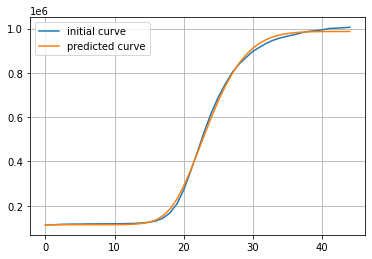

In [6]:
plt.plot(curve, label = 'initial curve')

D_e_pred = simulate_vals(D_init=Decimal(10**res.x[0]),
                    E_init=Decimal(10**res.x[1]), 
                    P_init=Decimal(10**res.x[2]), 
                    delta_e=Decimal(10**res.x[4]),
                    n_d=Decimal(10**0),
                    n_dE=Decimal(10**0),
                    k_C=Decimal(10**res.x[7]),
                    beta=Decimal(10**res.x[8]),
                    n_cycle=44)[2]

D_e_pred = np.array([float(str(x)) + 10**res.x[3] for x in D_e_pred])

plt.plot(D_e_pred, label = 'predicted curve')
plt.legend()
plt.grid()

## Validation on multiple curves

In [11]:
import pandas as pd
val_curves = pd.read_csv("data/opt_valset.csv")
val_curves.head(5)

# print(val_curves.shape)
# print(type(curve))
# print(curve.shape)

,curve_idx,target,amp_score,cq,cycle_no,rn,drn,Fn,pcr_plate,sample_type,igi_call
0,23677,MS2,2.388084,25.285821128516332,1,229219.609375,-1374.626328,229219.61,AC00DB1I,Clinical Sample,Positive
1,23677,MS2,2.388084,25.285821128516332,2,229516.937500,-1170.968546,229516.94,AC00DB1I,Clinical Sample,Positive
2,23677,MS2,2.388084,25.285821128516332,3,230569.781250,-211.795139,230569.78,AC00DB1I,Clinical Sample,Positive
3,23677,MS2,2.388084,25.285821128516332,4,231039.625000,164.378268,231039.62,AC00DB1I,Clinical Sample,Positive
4,23677,MS2,2.388084,25.285821128516332,5,230943.109375,-25.807700,230943.11,AC00DB1I,Clinical Sample,Positive


### Convert validation data into arrays

In [12]:
# Initialize an empty dictionary
curve_dict = {}

# Initialize variables to track the current cycle and array
current_cycle = None
current_array = None

# Iterate over each row in the DataFrame
for index, row in val_curves.iterrows():
    curve_idx = row['curve_idx']
    cycle_no = row['cycle_no']
    Fn = row['Fn']

    # Create a new array if cycle_no resets to 1
    if cycle_no == 1:
        current_array = []
        
    # Append Fn to the current array
    current_array.append(Fn)

    # Save the array in the dictionary with key as curve_idx
    curve_dict[curve_idx] = current_array.copy()

# Output the dictionary
print(curve_dict)

{23677: [229219.61, 229516.94, 230569.78, 231039.62, 230943.11, 230716.08, 230738.72, 231506.53, 231881.64, 231403.33, 231121.1, 231270.34, 232347.42, 232583.56, 232420.75, 232218.86, 231576.52, 231489.69, 232237.1, 232335.8, 232360.58, 233107.52, 233559.84, 234792.33, 236167.22, 239115.5, 244746.55, 251284.23, 259784.92, 269840.06, 282681.1, 297658.06, 312901.47, 329566.8, 347342.06, 364913.8, 383243.47, 399506.16, 414237.06, 426192.12], 23827: [225227.69, 225484.0, 226158.3, 226503.12, 226652.75, 227078.83, 227089.17, 227114.14, 226987.95, 226832.52, 226757.75, 226968.16, 226995.47, 227085.25, 226990.39, 226928.94, 226880.67, 226871.75, 227049.5, 227176.38, 227102.89, 227260.45, 228102.67, 229347.3, 231038.64, 234510.11, 239952.72, 247267.86, 255982.25, 267886.97, 281850.6, 297396.7, 315155.75, 334287.1, 353652.88, 374252.4, 394581.47, 413789.8, 431580.06, 445970.53], 23900: [229257.72, 229768.98, 230963.02, 231039.84, 230871.23, 230891.53, 231116.3, 231109.84, 231297.89, 231160.23, 

In [18]:
#Get target dataframe
target_data = val_curves.groupby('curve_idx').tail(1)

print(target_data.head(5))
print(target_data['sample_type'].unique())
print(target_data.groupby('sample_type').count())

print(target_data.shape)
print(len(target_data['curve_idx'].unique()))



     curve_idx  target  amp_score                  cq  cycle_no  \
39       23677     MS2   2.388084  25.285821128516332        40   
79       23827     MS2   2.411084   25.07951713476232        40   
119      23900     MS2   2.297453  25.197460254036216        40   
159      25090  S gene   2.145592   28.70093986035272        40   
199      23975     MS2   2.163302   25.14350626845352        40   

                rn            drn         Fn pcr_plate  \
39   426192.125000  191944.745915  426192.12  AC00DB1I   
79   445970.531250  218357.165625  445970.53  AC00DB1I   
119  401292.343750  170586.391506  401292.34  AC00DB1I   
159  238620.828125   56947.925824  238620.83  AC00DB1I   
199  322850.781250   97378.915372  322850.78  AC00DB1I   

                 sample_type  igi_call  
39           Clinical Sample  Positive  
79           Clinical Sample  Positive  
119          Clinical Sample  Positive  
159  Positive Control (qPCR)  Positive  
199          Clinical Sample  Positive  
['

In [21]:
#Filter down to ground truth 
ground_truth_targets = target_data[target_data['sample_type']!='Clinical Sample']
print(ground_truth_targets.shape)

(220, 11)


### Implementing eval loop

In [58]:
for index, row in ground_truth_targets.iterrows():
    
    #get curve corresponding to row
    curve = curve_dict[row['curve_idx']]
    print(len(curve))
    
    print(int(len(curve)))
    
    n_cycle = 45
    print(n_cycle)
    
    #instantiate
    init_params = np.array([4, 6, 5, 5, 1, 0, 0, 1, 1, n_cycle])
    
    #perform optimization
    res = minimize(func_to_optimize, init_params, method='nelder-mead', options={'xatol': 1e-2, 'disp': True})
    
    #get the predicted curve
    D_e_pred = simulate_vals(D_init=Decimal(10**res.x[0]),
                    E_init=Decimal(10**res.x[1]), 
                    P_init=Decimal(10**res.x[2]), 
                    delta_e=Decimal(10**res.x[4]),
                    n_d=Decimal(10**0),
                    n_dE=Decimal(10**0),
                    k_C=Decimal(10**res.x[7]),
                    beta=Decimal(10**res.x[8]),
                    n_cycle=44)[2]

    D_e_pred = np.array([float(str(x)) + 10**res.x[3] for x in D_e_pred])
    
    mse = ((curve - D_e_cur)**2).mean()
    break
    
    #calculate mse relative to real curve
    
    
    

40
40
45
45
0.1
0.1813138818870419426502424631
0.3154081533702388514980571159
0.5274589492986101587448900061
0.8550388039616851492194829058
1.358947221385334824935031884
2.142953093117437925888396983
3.391201041215617457806967036
5.443089121318054334980442668
8.950772788963616171764308941
15.22711693620970082996624270
27.05570008110354094354676668
50.68751883003984765206817319
101.0826044266936839831439311
216.6574441574466078729466850
504.0746984558813686547041400
1286.272244093077744965377060
3639.683722061077502226948917
11557.06437627723122382080174
41718.58907414474903078043534
173673.8982133551291064687344
847142.0601551463687783665096
4927713.231331238061323530817
34857779.46422020380386831911
306450247.6053981238935571694
3430171306.130281328040836018
50213707645.67994669403260622
990443006085.2711052639849768
27209864457130.44562685393062
1080191360119659.111905931671
64553026920732273.03751751382
6077319504302478475.444095562
948021383809896329111.8720768
25918069457296491146

9832464989872.290524483165901
328844168865129.0275130037230
16137311113854777.95637437019
1211643714851445564.122254732
145813535467893691264.5084566
29612857353054786358225.60257
10746017793916884807507343.54
7423976626691312312644243632
1.047592879838958877628291026E+31
3.264353214125925415432559508E+34
2.449251192369105887249495962E+38
4.870678366958696338909777751E+42
2.855668562695604685342731973E+47
5.554974056578244708360517050E+52
4.087040984328011056868982134E+58
1.315227140689536216229696313E+65
2.175021826664193602483554641E+72
45
0.1105337902709433622416853135
0.1987829814589926996051447147
0.3427919501568817272637957819
0.5686851325161876353875284645
0.9158598416789159114458874401
1.448445914644486882338841425
2.276075835262965468324688130
3.593299021184141391621405834
5.758508997975364725417289202
9.459803760770638774220441149
16.08076271307708783854225319
28.54995037514012552078459335
53.42869923153304952412870932
106.3710979996847578468940411
227.41352739490733490197848

InvalidOperation: [<class 'decimal.InvalidOperation'>]